<a href="https://colab.research.google.com/github/OfirW3/IIoT-NIDS-Technion-ML-Course-Final-Project/blob/main/notebooks/test_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# BLOCK 1: DYNAMIC IMPORTS & SETUP
# ==========================================
import sys
import subprocess
from datetime import datetime

def now():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print(f"[{now()}] Checking and loading required modules...")

# Helper function to install missing packages
def install_module(package_name):
    print(f"[{now()}] Module missing. Installing {package_name}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

# Dynamically import or install
try:
    import sklearn
except ImportError:
    install_module("scikit-learn")
    import sklearn

try:
    import xgboost as xgb
except ImportError:
    install_module("xgboost")
    import xgboost as xgb

try:
    import pytorch_tabnet
except ImportError:
    install_module("pytorch-tabnet")
    import pytorch_tabnet

try:
    import tensorflow as keras
except ImportError:
    install_module("tensorflow")
    import tensorflow as keras

# Now import the specific classes and functions safely
import os
import pandas as pd
import numpy as np
import joblib
from pytorch_tabnet.tab_model import TabNetClassifier
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print(f"[{now()}] All modules loaded successfully.")

[2026-03-29 14:02:11] Checking and loading required modules...
[2026-03-29 14:02:13] Module missing. Installing pytorch-tabnet...
[2026-03-29 14:02:39] All modules loaded successfully.


In [2]:
# ==========================================
# BLOCK 2: LOAD TEST DATA & PREPROCESSORS
# ==========================================
print(f"[{now()}] Loading Test Data and Preprocessors...")

BASE_DIR = "/content/drive/MyDrive/CIC_IIOT_2025/"

# 1. Load Preprocessors
scaler = joblib.load(os.path.join(BASE_DIR, "standard_scaler.pkl"))
le_multi = joblib.load(os.path.join(BASE_DIR, "label_encoder_multi.pkl"))

# 2. Load Holdout Test Data
test_df = pd.read_csv(os.path.join(BASE_DIR, "test_dataset.csv"))

# 3. Separate Features and Targets
y_test_bin = test_df['label1'].values
y_test_multi = le_multi.transform(test_df['label2'].astype(str))
X_test_raw = test_df.drop(columns=['label1', 'label2'])

# 4. Scale Features
X_test_scaled = scaler.transform(X_test_raw)

print(f"[{now()}] Test Data Loaded & Scaled. Test set size: {X_test_scaled.shape[0]} rows.")

[2026-03-29 14:02:39] Loading Test Data and Preprocessors...
[2026-03-29 14:02:41] Test Data Loaded & Scaled. Test set size: 4978 rows.


In [3]:
# ==========================================
# BLOCK 3: LOAD ALL SAVED MODELS
# ==========================================
print(f"[{now()}] Loading Models from Drive...")

BASE_DIR = "/content/drive/MyDrive/CIC_IIOT_2025/"

# Scikit-Learn Models
rf_bin = joblib.load(os.path.join(BASE_DIR, "rf_bin_model.pkl"))
rf_multi = joblib.load(os.path.join(BASE_DIR, "rf_multi_model.pkl"))
iso_forest = joblib.load(os.path.join(BASE_DIR, "iso_forest_model.pkl"))

# TabNet Models
tabnet_bin = TabNetClassifier()
tabnet_bin.load_model(os.path.join(BASE_DIR, "tabnet_bin_model.zip"))

tabnet_multi = TabNetClassifier()
tabnet_multi.load_model(os.path.join(BASE_DIR, "tabnet_multi_model.zip"))

# Keras Encoder
encoder = keras.models.load_model(os.path.join(BASE_DIR, "encoder_model.keras"))

# XGBoost Models
xgb_bin = xgb.XGBClassifier()
xgb_bin.load_model(os.path.join(BASE_DIR, "xgb_bin_model.json"))

xgb_multi = xgb.XGBClassifier()
xgb_multi.load_model(os.path.join(BASE_DIR, "xgb_multi_model.json"))

print(f"[{now()}] All 7 models successfully loaded.")

[2026-03-29 14:02:41] Loading Models from Drive...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


[2026-03-29 14:02:50] All 7 models successfully loaded.


In [4]:
# ==========================================
# BLOCK 4: GENERATE LATENT FEATURES FOR XGBOOST
# ==========================================
print(f"[{now()}] Generating latent features using Autoencoder...")

X_test_enc = encoder.predict(X_test_scaled, verbose=0)

print(f"[{now()}] Latent features generated. Shape: {X_test_enc.shape}")

[2026-03-29 14:02:51] Generating latent features using Autoencoder...
[2026-03-29 14:02:54] Latent features generated. Shape: (4978, 32)


In [5]:
# ==========================================
# BLOCK 5: RUN PREDICTIONS & COLLECT METRICS
# ==========================================
print(f"[{now()}] Evaluating models on unseen test data...")

results = []

# --- BINARY PREDICTIONS ---
rf_bin_preds = rf_bin.predict(X_test_raw)
results.append({"Model": "Random Forest", "Task": "Binary", "Accuracy": accuracy_score(y_test_bin, rf_bin_preds), "F1-Score": f1_score(y_test_bin, rf_bin_preds)})

tabnet_bin_preds = tabnet_bin.predict(X_test_raw.values)
results.append({"Model": "TabNet", "Task": "Binary", "Accuracy": accuracy_score(y_test_bin, tabnet_bin_preds), "F1-Score": f1_score(y_test_bin, tabnet_bin_preds)})

xgb_bin_preds = xgb_bin.predict(X_test_enc)
results.append({"Model": "Hybrid XGBoost", "Task": "Binary", "Accuracy": accuracy_score(y_test_bin, xgb_bin_preds), "F1-Score": f1_score(y_test_bin, xgb_bin_preds)})

iso_preds_raw = iso_forest.predict(X_test_scaled)
iso_preds = np.where(iso_preds_raw == 1, 0, 1) # Convert 1/-1 to 0/1
results.append({"Model": "Isolation Forest", "Task": "Binary", "Accuracy": accuracy_score(y_test_bin, iso_preds), "F1-Score": f1_score(y_test_bin, iso_preds)})

# --- MULTI-CLASS PREDICTIONS ---
rf_multi_preds = rf_multi.predict(X_test_raw)
results.append({"Model": "Random Forest", "Task": "Multi-Class", "Accuracy": accuracy_score(y_test_multi, rf_multi_preds), "F1-Score": f1_score(y_test_multi, rf_multi_preds, average='macro')})

tabnet_multi_preds = tabnet_multi.predict(X_test_raw.values)
results.append({"Model": "TabNet", "Task": "Multi-Class", "Accuracy": accuracy_score(y_test_multi, tabnet_multi_preds), "F1-Score": f1_score(y_test_multi, tabnet_multi_preds, average='macro')})

xgb_multi_preds = xgb_multi.predict(X_test_enc)
results.append({"Model": "Hybrid XGBoost", "Task": "Multi-Class", "Accuracy": accuracy_score(y_test_multi, xgb_multi_preds), "F1-Score": f1_score(y_test_multi, xgb_multi_preds, average='macro')})

results_df = pd.DataFrame(results)
print(f"[{now()}] Metrics successfully collected.")

[2026-03-29 14:02:54] Evaluating models on unseen test data...
[2026-03-29 14:02:57] Metrics successfully collected.


[2026-03-29 14:02:57] Generating visualization...


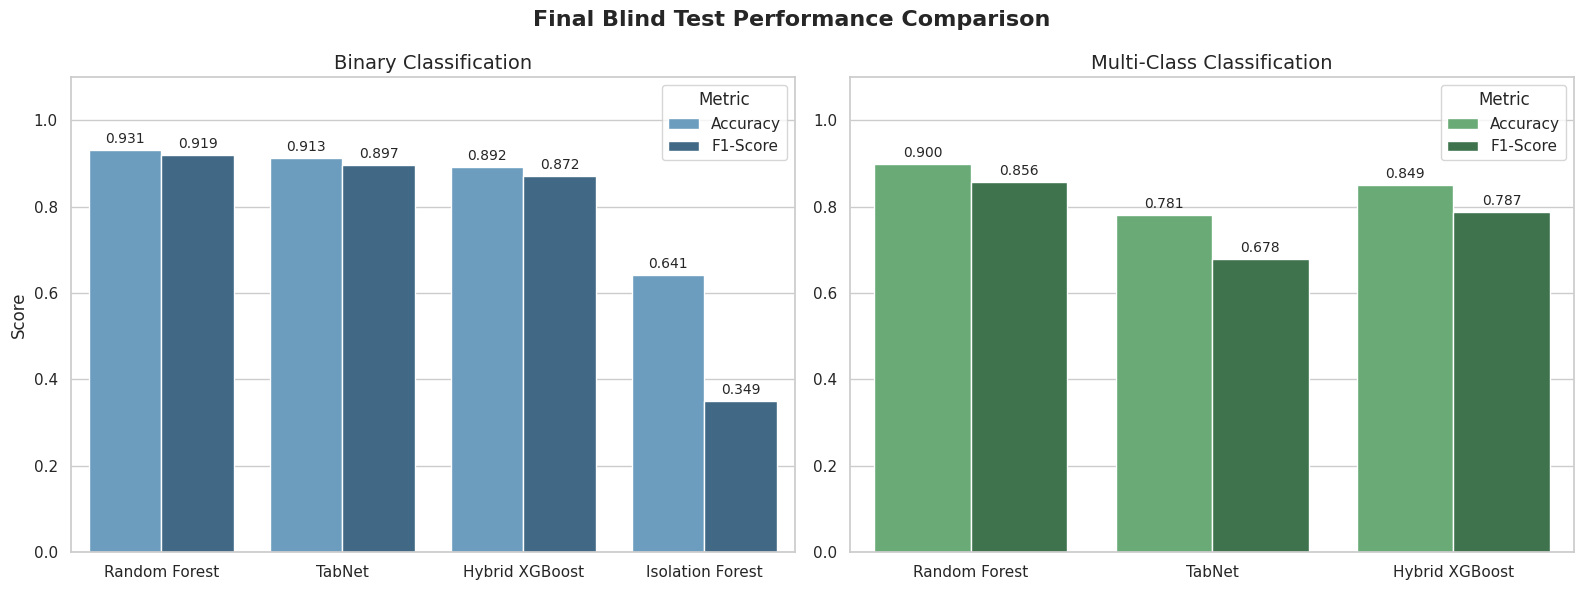

,Model,Task,Accuracy,F1-Score
0,Random Forest,Binary,0.9315,0.9189
1,TabNet,Binary,0.9126,0.8970
2,Hybrid XGBoost,Binary,0.8919,0.8716
3,Isolation Forest,Binary,0.6414,0.3488
4,Random Forest,Multi-Class,0.8998,0.8564
5,TabNet,Multi-Class,0.7812,0.6781
6,Hybrid XGBoost,Multi-Class,0.8493,0.7871


In [6]:
# ==========================================
# BLOCK 6: VISUALIZE COMPARISON GRAPH
# ==========================================
print(f"[{now()}] Generating visualization...")

# Melt the dataframe to plot Accuracy and F1-Score side-by-side easily in Seaborn
melted_df = results_df.melt(id_vars=["Model", "Task"], value_vars=["Accuracy", "F1-Score"], var_name="Metric", value_name="Score")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Final Blind Test Performance Comparison", fontsize=16, fontweight='bold')

# 1. Binary Plot
sns.barplot(data=melted_df[melted_df["Task"] == "Binary"], x="Model", y="Score", hue="Metric", ax=axes[0], palette="Blues_d")
axes[0].set_title("Binary Classification", fontsize=14)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Score")
axes[0].set_xlabel("")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', padding=3, size=10)

# 2. Multi-Class Plot (No Isolation Forest here)
sns.barplot(data=melted_df[melted_df["Task"] == "Multi-Class"], x="Model", y="Score", hue="Metric", ax=axes[1], palette="Greens_d")
axes[1].set_title("Multi-Class Classification", fontsize=14)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("")
axes[1].set_xlabel("")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=3, size=10)

plt.tight_layout()
plt.show()

# Display the raw numbers underneath for good measure
display(results_df.round(4))